# Baseline Forecasting Models

The objective of this notebook is to establish classical forecasting baselines for the bike-sharing demand prediction task.

The following forecasting models are evaluated:
- Naive Forecast
- Seasonal Naive Forecast
- AutoARIMA

The models are evaluated using:
- MAE
- RMSE
- MASE

All models use the same chronological train-validation-test split to ensure fair comparison and reproducibility.

In [1]:
# imports
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import warnings
warnings.filterwarnings("ignore")

C:\Users\48661\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# loading data
train = pd.read_csv(
    "../data/processed/train.csv",
    index_col=0,
    parse_dates=True
)

val = pd.read_csv(
    "../data/processed/val.csv",
    index_col=0,
    parse_dates=True
)

test = pd.read_csv(
    "../data/processed/test.csv",
    index_col=0,
    parse_dates=True
)

In [3]:
# data check
print(train.shape)
print(val.shape)
print(test.shape)

train.head()

(12165, 13)
(3475, 13)
(1739, 13)


,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,hum,windspeed,cnt
datetime,,,,,,,,,,,,,
2011-01-01 00:00:00,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.81,0.0,16
2011-01-01 01:00:00,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.80,0.0,40
2011-01-01 02:00:00,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.80,0.0,32
2011-01-01 03:00:00,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.75,0.0,13
2011-01-01 04:00:00,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.75,0.0,1


In [4]:
# defining metrics
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def mase(y_true, y_pred, train_series):
    
    naive_forecast = train_series[:-1]
    naive_actual = train_series[1:]
    
    mae_naive = mean_absolute_error(
        naive_actual,
        naive_forecast
    )
    
    mae_model = mean_absolute_error(
        y_true,
        y_pred
    )
    
    return mae_model / mae_naive


def evaluate_forecast(
    y_true,
    y_pred,
    train_series
):
    
    results = {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MASE": mase(y_true, y_pred, train_series)
    }
    
    return results

In [5]:
# test metrics
evaluate_forecast(
    val["cnt"],
    val["cnt"],
    train["cnt"]
)

{'MAE': 0.0, 'RMSE': 0.0, 'MASE': 0.0}

## Naive Forecast

The Naive Forecast predicts the next observation using the most recent observed value.

Formally:

\[
\hat{y}_t = y_{t-1}
\]

This model serves as a simple baseline for evaluating whether more advanced forecasting approaches provide meaningful improvements.

In [6]:
# validation forecast
naive_val_pred = val["cnt"].shift(1)

In [7]:
naive_val_pred.head()

datetime
2012-05-27 02:00:00     NaN
2012-05-27 03:00:00    61.0
2012-05-27 04:00:00    36.0
2012-05-27 05:00:00    11.0
2012-05-27 06:00:00     7.0
Name: cnt, dtype: float64

In [8]:
naive_val_pred = naive_val_pred.dropna()

val_actual = val["cnt"].iloc[1:]

In [9]:
# evaluation
naive_val_results = evaluate_forecast(
    val_actual,
    naive_val_pred,
    train["cnt"]
)

naive_val_results

{'MAE': 95.06102475532528,
 'RMSE': 139.74786696491478,
 'MASE': 1.7095901160064944}

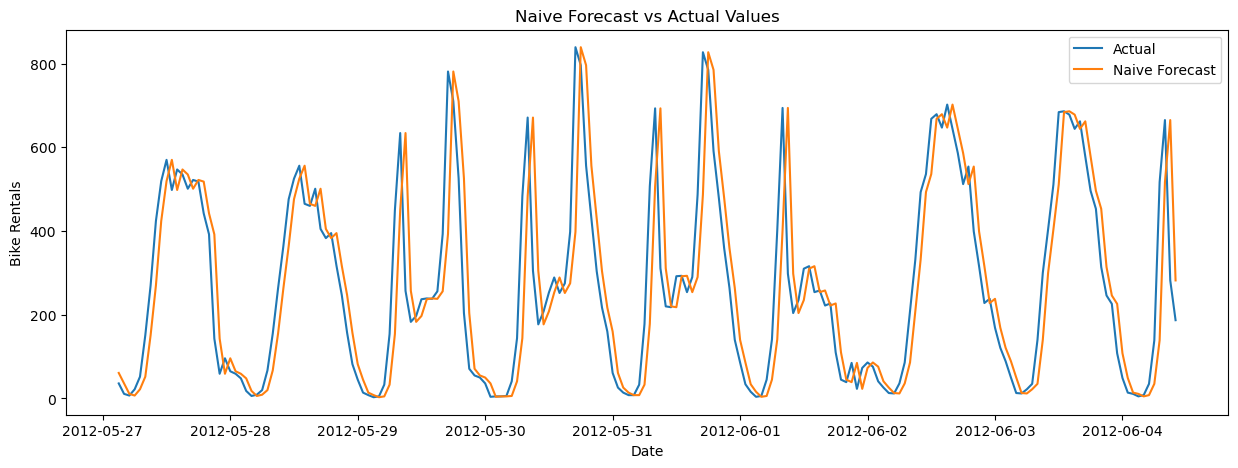

In [10]:
plt.figure(figsize=(15,5))

plt.plot(
    val_actual.index[:200],
    val_actual[:200],
    label="Actual"
)

plt.plot(
    naive_val_pred.index[:200],
    naive_val_pred[:200],
    label="Naive Forecast"
)

plt.title("Naive Forecast vs Actual Values")
plt.xlabel("Date")
plt.ylabel("Bike Rentals")

plt.legend()

plt.show()

The Naive Forecast captures short-term local continuity in the series but fails to model recurring daily seasonal patterns.

The relatively high forecasting errors suggest that relying only on the previous observation is insufficient for accurately predicting hourly bike rental demand.

This result indicates that explicit seasonality-aware forecasting approaches may provide substantial improvements.

In [11]:
# test forecast
naive_test_pred = test["cnt"].shift(1)

naive_test_pred = naive_test_pred.dropna()

test_actual = test["cnt"].iloc[1:]

In [12]:
# evaluation
naive_test_results = evaluate_forecast(
    test_actual,
    naive_test_pred,
    train["cnt"]
)

naive_test_results

{'MAE': 69.92635212888378,
 'RMSE': 109.63443807265799,
 'MASE': 1.25756481960534}

In [13]:
# validation vs test results comparison
naive_results_df = pd.DataFrame({
    "Validation": naive_val_results,
    "Test": naive_test_results
})

naive_results_df

,Validation,Test
MAE,95.061025,69.926352
RMSE,139.747867,109.634438
MASE,1.709590,1.257565


The Naive Forecast achieves relatively high forecasting errors on both the validation and test sets.

Although the model captures short-term continuity in the series, it fails to account for the strong daily seasonal structure identified during exploratory analysis.

This suggests that seasonality-aware forecasting approaches are likely to provide substantially better predictive performance.

## Seasonal Naive Forecast

The Seasonal Naive Forecast predicts future observations using the value observed during the same seasonal period in the past.

Given the strong daily seasonality identified during exploratory analysis, a seasonal period of 24 hours is used:

\[
\hat{y}_t = y_{t-24}
\]

This approach allows the model to capture recurring daily demand cycles.

In [14]:
# validation forecast 
seasonal_naive_val_pred = val["cnt"].shift(24)

In [15]:
seasonal_naive_val_pred = (
    seasonal_naive_val_pred.dropna()
)

seasonal_val_actual = val["cnt"].iloc[24:]

In [16]:
# evaluation
seasonal_naive_val_results = evaluate_forecast(
    seasonal_val_actual,
    seasonal_naive_val_pred,
    train["cnt"]
)

seasonal_naive_val_results

{'MAE': 84.93103448275862,
 'RMSE': 140.8822503416082,
 'MASE': 1.5274110232626859}

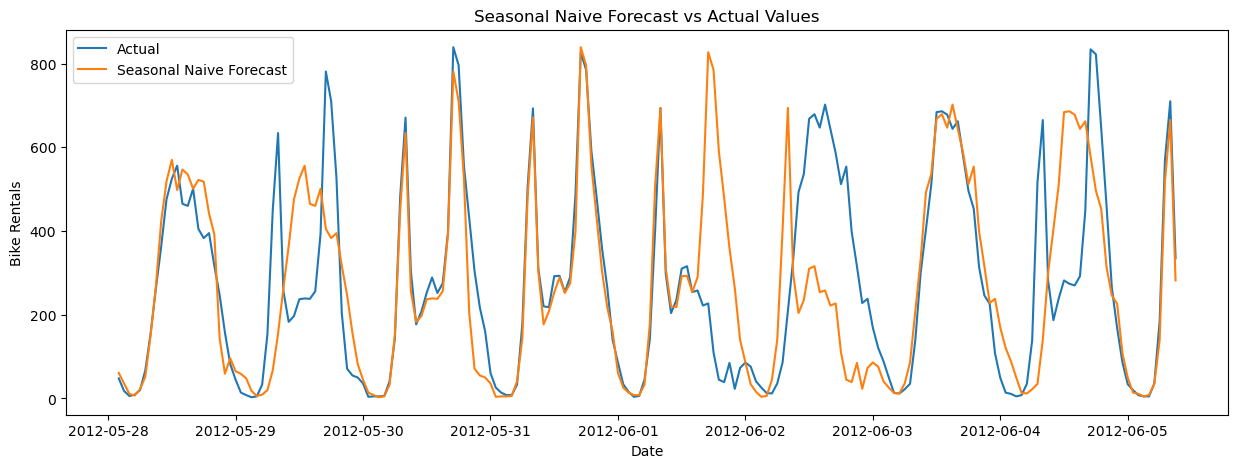

In [17]:
plt.figure(figsize=(15,5))

plt.plot(
    seasonal_val_actual.index[:200],
    seasonal_val_actual[:200],
    label="Actual"
)

plt.plot(
    seasonal_naive_val_pred.index[:200],
    seasonal_naive_val_pred[:200],
    label="Seasonal Naive Forecast"
)

plt.title("Seasonal Naive Forecast vs Actual Values")

plt.xlabel("Date")
plt.ylabel("Bike Rentals")

plt.legend()

plt.show()

The Seasonal Naive Forecast captures recurring daily demand cycles more effectively than the standard Naive Forecast.

Using observations from the same hour of the previous day improves short-term forecasting performance, particularly for regular commuting-related demand patterns.

However, the model still struggles to capture abrupt demand fluctuations and larger peaks, which contributes to relatively high RMSE values.

In [18]:
# test forecast
seasonal_naive_test_pred = (
    test["cnt"].shift(24)
)

seasonal_naive_test_pred = (
    seasonal_naive_test_pred.dropna()
)

seasonal_test_actual = (
    test["cnt"].iloc[24:]
)

In [19]:
# test evaluation
seasonal_naive_test_results = evaluate_forecast(
    seasonal_test_actual,
    seasonal_naive_test_pred,
    train["cnt"]
)

seasonal_naive_test_results

{'MAE': 74.22915451895044,
 'RMSE': 123.50846101255962,
 'MASE': 1.3349469902280588}

In [20]:
seasonal_results_df = pd.DataFrame({
    "Validation": seasonal_naive_val_results,
    "Test": seasonal_naive_test_results
})

seasonal_results_df

,Validation,Test
MAE,84.931034,74.229155
RMSE,140.882250,123.508461
MASE,1.527411,1.334947


In [21]:
comparison_df = pd.DataFrame({
    "Naive Validation": naive_val_results,
    "Naive Test": naive_test_results,
    "Seasonal Validation": seasonal_naive_val_results,
    "Seasonal Test": seasonal_naive_test_results
})

comparison_df

,Naive Validation,Naive Test,Seasonal Validation,Seasonal Test
MAE,95.061025,69.926352,84.931034,74.229155
RMSE,139.747867,109.634438,140.882250,123.508461
MASE,1.709590,1.257565,1.527411,1.334947


In [ ]:

AutoARIMA,
comparison,
conclusions.